<a href="https://colab.research.google.com/github/VakitiSriVarsha/Gen-AI/blob/main/Assignmen_1_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Twitter_Data.csv to Twitter_Data.csv


In [ ]:
import pandas as pd
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from wordcloud import WordCloud

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
df = pd.read_csv("Twitter_Data.csv")
df.head()

,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


In [ ]:
df.columns


Index(['clean_text', 'category'], dtype='object')

In [ ]:
df = df.dropna(subset=['category'])

In [ ]:
df['category'] = df['category'].astype(int)

In [ ]:
stop_words = set(stopwords.words('english'))

def clean_review(text):
    text = str(text).lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df['clean_text'] = df['clean_text'].apply(clean_review)

In [ ]:
X = df['clean_text']
y = df['category']   # -1, 0, 1

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
bow = CountVectorizer(max_features=5000)
X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)

In [ ]:
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [ ]:
nb = MultinomialNB()
nb.fit(X_train_bow, y_train)
nb_pred = nb.predict(X_test_bow)


In [ ]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf, y_train)
lr_pred = lr.predict(X_test_tfidf)

In [ ]:
print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))
print(classification_report(y_test, nb_pred))

Naive Bayes Accuracy: 0.7836477987421384
              precision    recall  f1-score   support

          -1       0.70      0.72      0.71      7230
           0       0.84      0.77      0.80     10961
           1       0.78      0.83      0.81     14404

    accuracy                           0.78     32595
   macro avg       0.78      0.77      0.77     32595
weighted avg       0.79      0.78      0.78     32595



In [ ]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.8921306948918546
              precision    recall  f1-score   support

          -1       0.88      0.78      0.83      7230
           0       0.86      0.97      0.91     10961
           1       0.92      0.89      0.90     14404

    accuracy                           0.89     32595
   macro avg       0.89      0.88      0.88     32595
weighted avg       0.89      0.89      0.89     32595



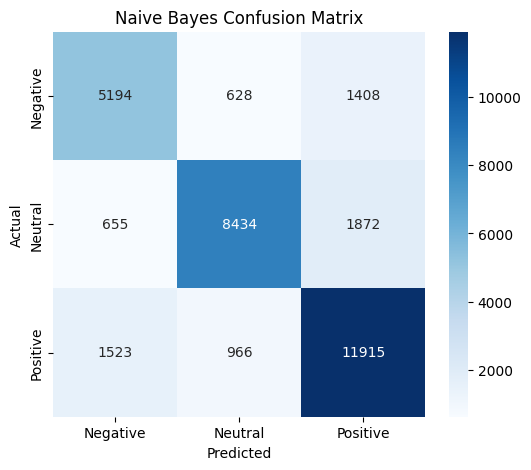

In [ ]:
cm_nb = confusion_matrix(y_test, nb_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Naive Bayes Confusion Matrix")
plt.show()

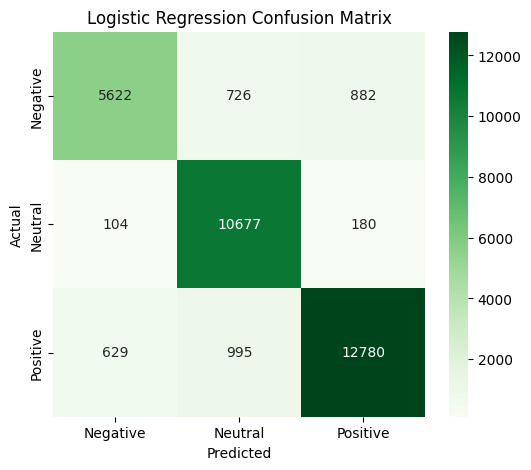

In [ ]:
cm_lr = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

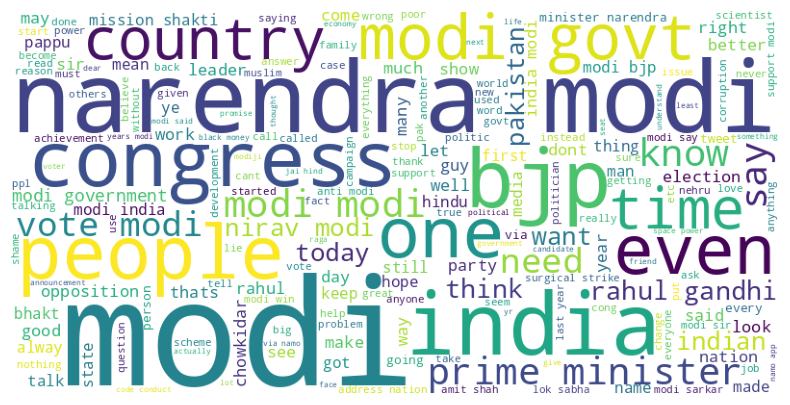

In [ ]:
text = " ".join(df['clean_text'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()